# Recruitment Acceptance Prediction - Full EDA & Modeling Notebook
# Capstone Project - Module 20.1

In [1]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)
from sklearn.feature_selection import RFE

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("=" * 80)
print("RECRUITMENT ACCEPTANCE PREDICTION - EDA & MODELING")
print("=" * 80)

RECRUITMENT ACCEPTANCE PREDICTION - EDA & MODELING


In [2]:
# =============================================================================
# 2. DATA LOADING
# =============================================================================

print("\n" + "=" * 60)
print("2. DATA LOADING")
print("=" * 60)

# Load HR data
hr_url = 'https://raw.githubusercontent.com/kimkok-UCBerkeleyHaas/Assignments/refs/heads/main/datasets/hr_data.csv'
df_hr = pd.read_csv(hr_url)

# Load recruitment data
rec_url = 'https://raw.githubusercontent.com/kimkok-UCBerkeleyHaas/Assignments/refs/heads/main/datasets/recruitment_data.csv'
df_rec = pd.read_csv(rec_url)

print(f"\nHR Data: {df_hr.shape[0]:,} rows, {df_hr.shape[1]} columns")
print(f"Recruitment Data: {df_rec.shape[0]:,} rows, {df_rec.shape[1]} columns")


2. DATA LOADING

HR Data: 8,995 rows, 18 columns
Recruitment Data: 1,500 rows, 11 columns


In [3]:
# =============================================================================
# 3. DATA EXPLORATION - HR DATA
# =============================================================================

print("\n" + "=" * 60)
print("3. HR DATA EXPLORATION")
print("=" * 60)

print("\n--- First 5 rows ---")
display(df_hr.head())

print("\n--- Data Info ---")
print(df_hr.info())

print("\n--- Missing Values ---")
print(df_hr.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df_hr.describe())


3. HR DATA EXPLORATION

--- First 5 rows ---


,SLNO,Candidate Ref,DOJ Extended,Duration to accept offer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Rex in Yrs,LOB,Location,Age,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SLNO                         8995 non-null   int64  
 1   Candidate Ref                8995 non-null   int64  
 2   DOJ Extended                 8995 non-null   object 
 3   Duration to accept offer     8995 non-null   int64  
 4   Notice period                8995 non-null   int64  
 5   Offered band                 8995 non-null   object 
 6   Pecent hike expected in CTC  8995 non-null   float64
 7   Percent hike offered in CTC  8995 non-null   float64
 8   Percent difference CTC       8995 non-null   float64
 9   Joining Bonus                8995 non-null   object 
 10  Candidate relocate actual    8995 non-null   object 
 11  Gender                       8995 non-null   object 
 12  Candidate Source             8995 non-null   object 
 13 

,SLNO,Candidate Ref,Duration to accept offer,Notice period,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Rex in Yrs,Age
count,8995.000000,8.995000e+03,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,5970.984325,2.843647e+06,21.434464,39.291829,43.864804,40.657356,-1.573802,4.239022,29.913174
std,3373.963454,4.863448e+05,25.811616,22.220239,29.788975,36.064060,19.610729,2.547571,4.097912
min,1.000000,2.109586e+06,0.000000,0.000000,-68.830000,-60.530000,-67.270000,0.000000,20.000000
25%,3207.500000,2.386476e+06,3.000000,30.000000,27.270000,22.090000,-8.330000,3.000000,27.000000
50%,5976.000000,2.807482e+06,10.000000,30.000000,40.000000,36.000000,0.000000,4.000000,29.000000
75%,8739.000000,3.300060e+06,33.000000,60.000000,53.850000,50.000000,0.000000,6.000000,34.000000
max,12333.000000,3.836076e+06,224.000000,120.000000,359.770000,471.430000,300.000000,24.000000,60.000000


In [4]:
# =============================================================================
# 4. DATA EXPLORATION - RECRUITMENT DATA
# =============================================================================

print("\n" + "=" * 60)
print("4. RECRUITMENT DATA EXPLORATION")
print("=" * 60)

print("\n--- First 5 rows ---")
display(df_rec.head())

print("\n--- Data Info ---")
print(df_rec.info())

print("\n--- Missing Values ---")
print(df_rec.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df_rec.describe())


4. RECRUITMENT DATA EXPLORATION

--- First 5 rows ---


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB
None

--- Missing Values ---
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompa

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.148667,0.492000,2.188000,7.694000,3.00200,25.505379,50.564000,51.116000,49.387333,1.893333,0.310000
std,9.252728,0.500103,0.862449,4.641414,1.41067,14.567151,28.626215,29.353563,29.353201,0.689642,0.462647
min,20.000000,0.000000,1.000000,0.000000,1.00000,1.031376,0.000000,0.000000,0.000000,1.000000,0.000000
25%,27.000000,0.000000,2.000000,4.000000,2.00000,12.838851,25.000000,25.750000,23.000000,1.000000,0.000000
50%,35.000000,0.000000,2.000000,8.000000,3.00000,25.502239,52.000000,53.000000,49.000000,2.000000,0.000000
75%,43.000000,1.000000,3.000000,12.000000,4.00000,37.737996,75.000000,76.000000,76.000000,2.000000,1.000000
max,50.000000,1.000000,4.000000,15.000000,5.00000,50.992462,100.000000,100.000000,100.000000,3.000000,1.000000


In [ ]:
# Visualize target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))





In [8]:
# =============================================================================
# 5. TARGET VARIABLE ANALYSIS
# =============================================================================

print("\n" + "=" * 60)
print("5. TARGET VARIABLE ANALYSIS")
print("=" * 60)

# HR Data Target
print("\n--- HR Data: Status Distribution ---")
status_counts = df_hr['Status'].value_counts()
status_pct = df_hr['Status'].value_counts(normalize=True) * 100
status_df = pd.DataFrame({'Count': status_counts, 'Percentage': status_pct})
display(status_df)

# Recruitment Data Target
print("\n--- Recruitment Data: Hiring Decision Distribution ---")
hiring_counts = df_rec['HiringDecision'].value_counts()
hiring_pct = df_rec['HiringDecision'].value_counts(normalize=True) * 100
hiring_df = pd.DataFrame({'Count': hiring_counts, 'Percentage': hiring_pct})
display(hiring_df)




5. TARGET VARIABLE ANALYSIS

--- HR Data: Status Distribution ---


,Count,Percentage
Status,,
Joined,7313,81.300723
Not Joined,1682,18.699277



--- Recruitment Data: Hiring Decision Distribution ---


,Count,Percentage
HiringDecision,,
0,1035,69.0
1,465,31.0


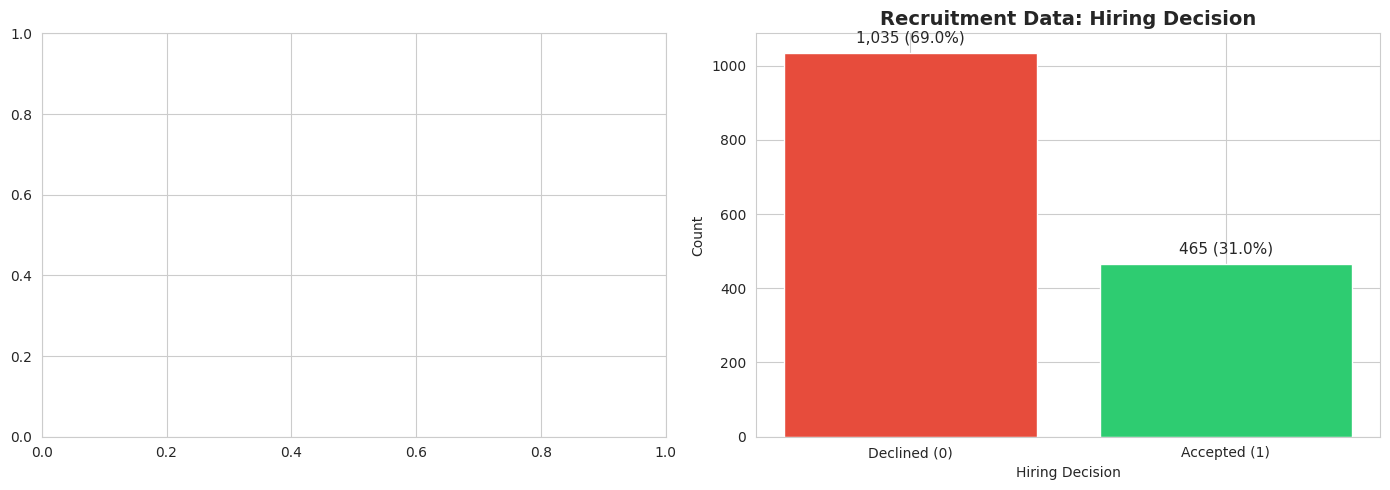

In [54]:
# Visualize target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recruitment Data
ax2 = axes[1]

counts = [hiring_counts.get(0, 0), hiring_counts.get(1, 0)]
percentages = [hiring_pct.get(0, 0), hiring_pct.get(1, 0)]

bars2 = ax2.bar(
       ['Declined (0)', 'Accepted (1)'],
        counts,
    color=['#e74c3c', '#2ecc71']
 )

ax2.set_title('Recruitment Data: Hiring Decision', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hiring Decision')
ax2.set_ylabel('Count')

for bar, count, pct in zip(bars2, counts, percentages):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{count:,} ({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [16]:
# =============================================================================
# 6. DATA CLEANING - HR DATA
# =============================================================================

print("\n" + "=" * 60)
print("6. DATA CLEANING - HR DATA")
print("=" * 60)

# Create a copy for cleaning
df_hr_clean = df_hr.copy()

# Convert Status to binary (1 = Joined, 0 = Not Joined)
df_hr_clean['Status_Binary'] = (df_hr_clean['Status'] == 'Joined').astype(int)

# Clean column names
df_hr_clean.columns = df_hr_clean.columns.str.strip()

# Handle missing values - check again
print("\n--- Missing values after cleanup ---")
print(df_hr_clean.isnull().sum())

# Convert DOJ Extended to binary
df_hr_clean['DOJ_Extended'] = df_hr_clean['DOJ Extended'].map({'Yes': 1, 'No': 0})

# Convert Candidate relocate actual to binary
df_hr_clean['Relocate_Required'] = df_hr_clean['Candidate relocate actual'].map({'Yes': 1, 'No': 0})

# Convert Gender to binary
df_hr_clean['Gender_Binary'] = df_hr_clean['Gender'].map({'Male': 1, 'Female': 0})

# Convert Joining Bonus to binary
df_hr_clean['Joining_Bonus'] = df_hr_clean['Joining Bonus'].map({'Yes': 1, 'No': 0})

print("\n--- Data types after cleaning ---")
print(df_hr_clean.dtypes)


6. DATA CLEANING - HR DATA

--- Missing values after cleanup ---
SLNO                           0
Candidate Ref                  0
DOJ Extended                   0
Duration to accept offer       0
Notice period                  0
Offered band                   0
Pecent hike expected in CTC    0
Percent hike offered in CTC    0
Percent difference CTC         0
Joining Bonus                  0
Candidate relocate actual      0
Gender                         0
Candidate Source               0
Rex in Yrs                     0
LOB                            0
Location                       0
Age                            0
Status                         0
Status_Binary                  0
dtype: int64

--- Data types after cleaning ---
SLNO                             int64
Candidate Ref                    int64
DOJ Extended                    object
Duration to accept offer         int64
Notice period                    int64
Offered band                    object
Pecent hike expected in C

In [17]:
# =============================================================================
# 7. FEATURE ENGINEERING - HR DATA
# =============================================================================

print("\n" + "=" * 60)
print("7. FEATURE ENGINEERING - HR DATA")
print("=" * 60)

# Create Salary Satisfaction Flag
df_hr_clean['Salary_Satisfaction'] = np.where(
    df_hr_clean['Percent hike offered in CTC'] >= df_hr_clean['Pecent hike expected in CTC'], 1, 0
)

# Create Expected_vs_Offered_Ratio
df_hr_clean['Expected_Offered_Ratio'] = (
    df_hr_clean['Pecent hike expected in CTC'] / (df_hr_clean['Percent hike offered in CTC'] + 0.01)
)

# Create Experience Category
df_hr_clean['Experience_Category'] = pd.cut(
    df_hr_clean['Rex in Yrs'],
    bins=[-1, 2, 5, 10, 20, 50],
    labels=['0-2', '3-5', '6-10', '11-20', '20+']
)

# Create Location Category
def categorize_location(loc):
    if loc in ['Noida', 'Gurgaon']:
        return 'NCR'
    elif loc in ['Bangalore', 'Chennai', 'Hyderabad']:
        return 'South'
    elif loc in ['Mumbai', 'Pune']:
        return 'West'
    else:
        return 'Other'

df_hr_clean['Location_Category'] = df_hr_clean['Location'].apply(categorize_location)

# Create Age Category
df_hr_clean['Age_Category'] = pd.cut(
    df_hr_clean['Age'],
    bins=[20, 25, 30, 35, 40, 50],
    labels=['20-25', '26-30', '31-35', '36-40', '40+']
)

# Create CTC Difference Flag
df_hr_clean['CTC_Diff_Flag'] = np.where(
    df_hr_clean['Percent difference CTC'] > 0, 'Positive',
    np.where(df_hr_clean['Percent difference CTC'] < 0, 'Negative', 'Zero')
)

print("\n--- New features created ---")
print(f"Salary_Satisfaction: {df_hr_clean['Salary_Satisfaction'].value_counts().to_dict()}")
print(f"Experience_Category: {df_hr_clean['Experience_Category'].value_counts().to_dict()}")
print(f"Location_Category: {df_hr_clean['Location_Category'].value_counts().to_dict()}")


7. FEATURE ENGINEERING - HR DATA

--- New features created ---
Salary_Satisfaction: {1: 5023, 0: 3972}
Experience_Category: {'3-5': 4807, '6-10': 2144, '0-2': 1849, '11-20': 192, '20+': 3}
Location_Category: {'South': 5721, 'NCR': 2873, 'West': 245, 'Other': 156}



8. UNIVARIATE ANALYSIS - HR DATA


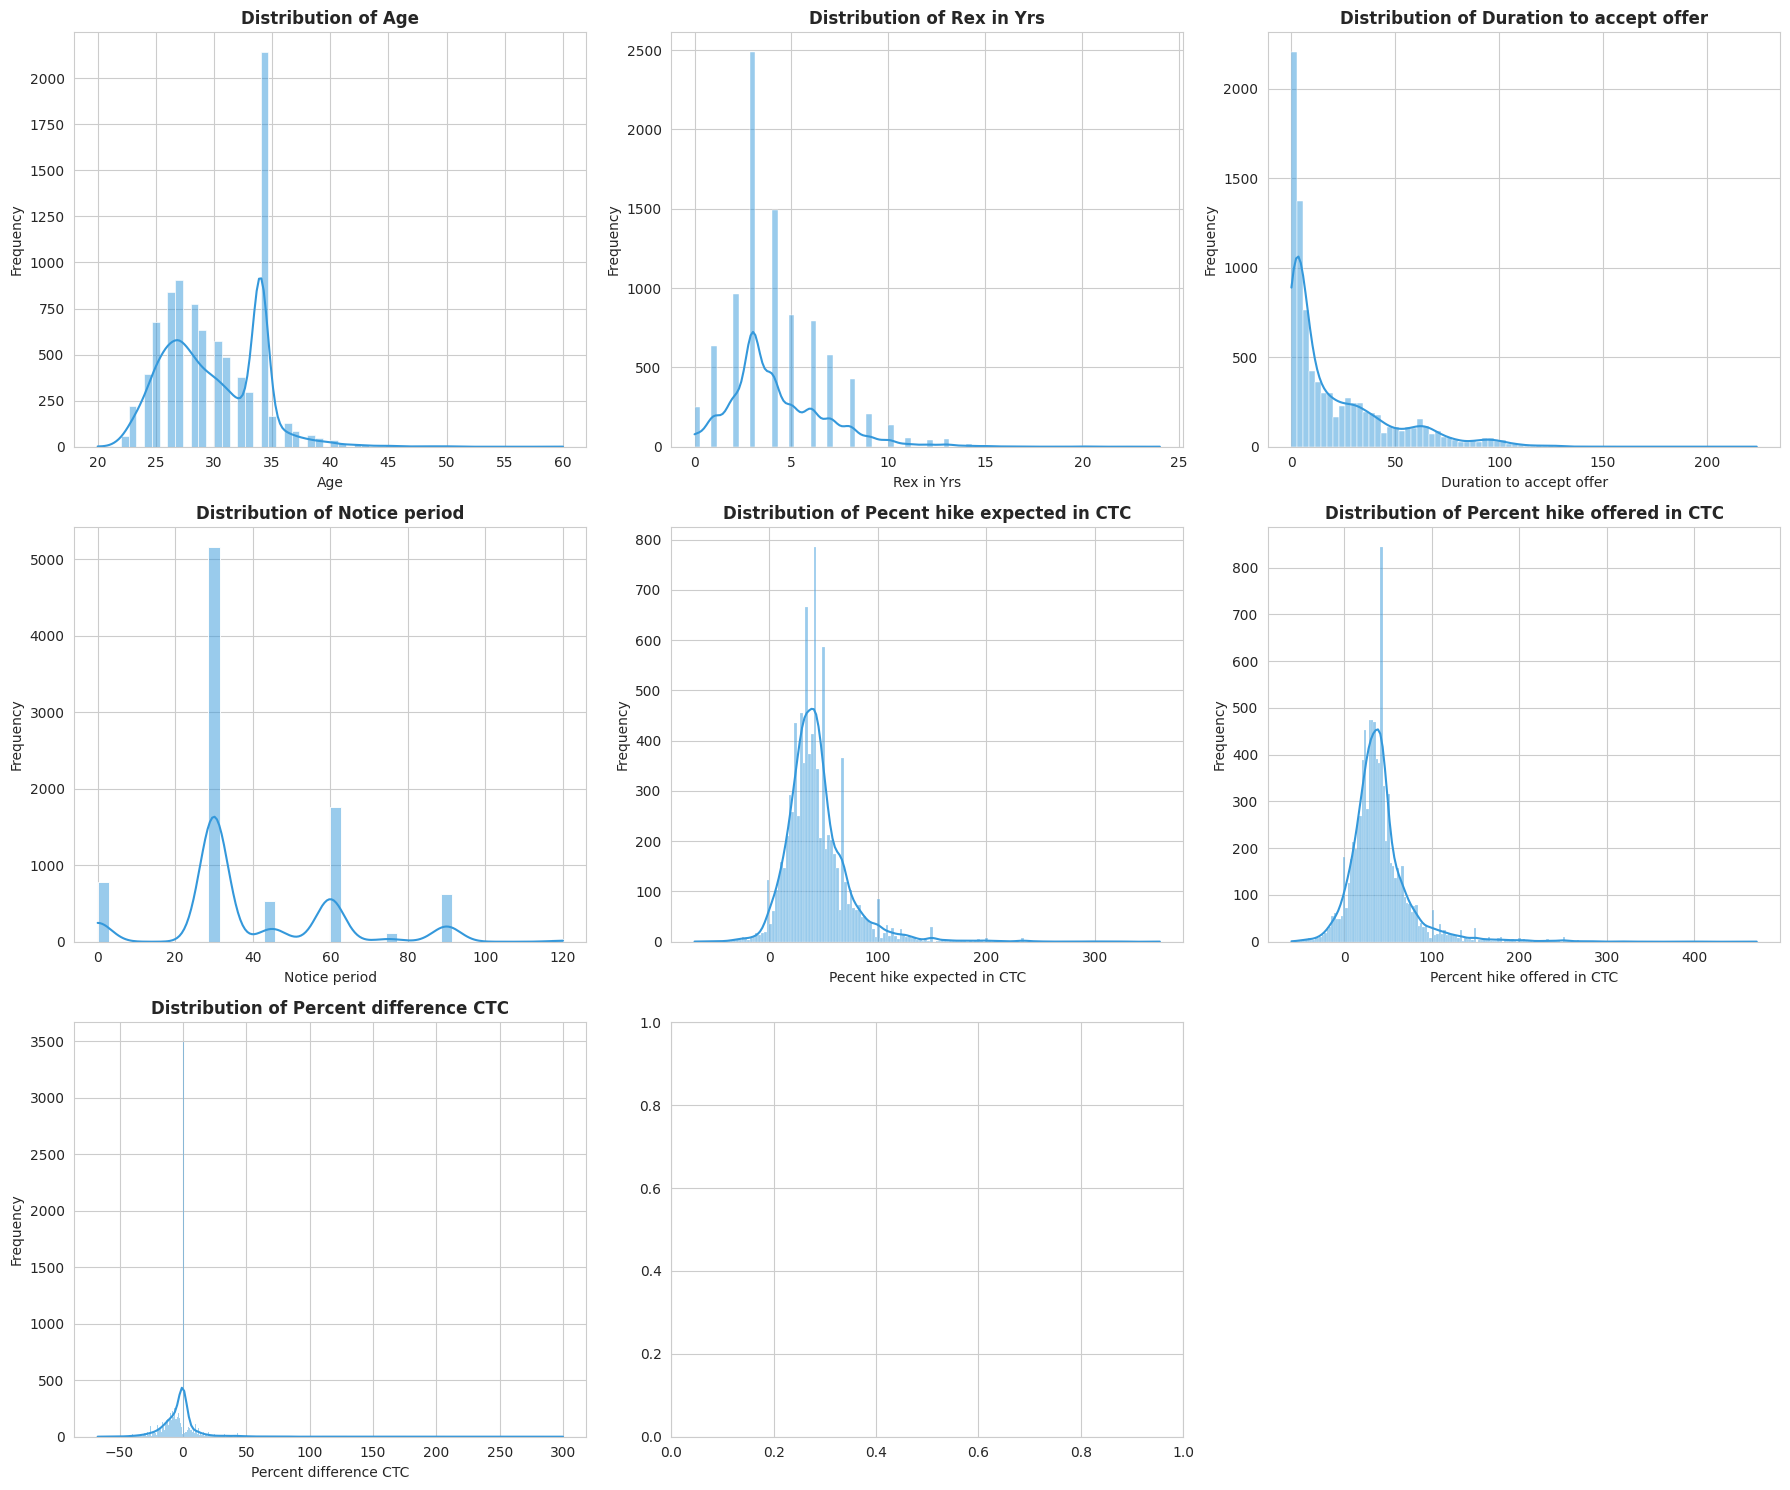

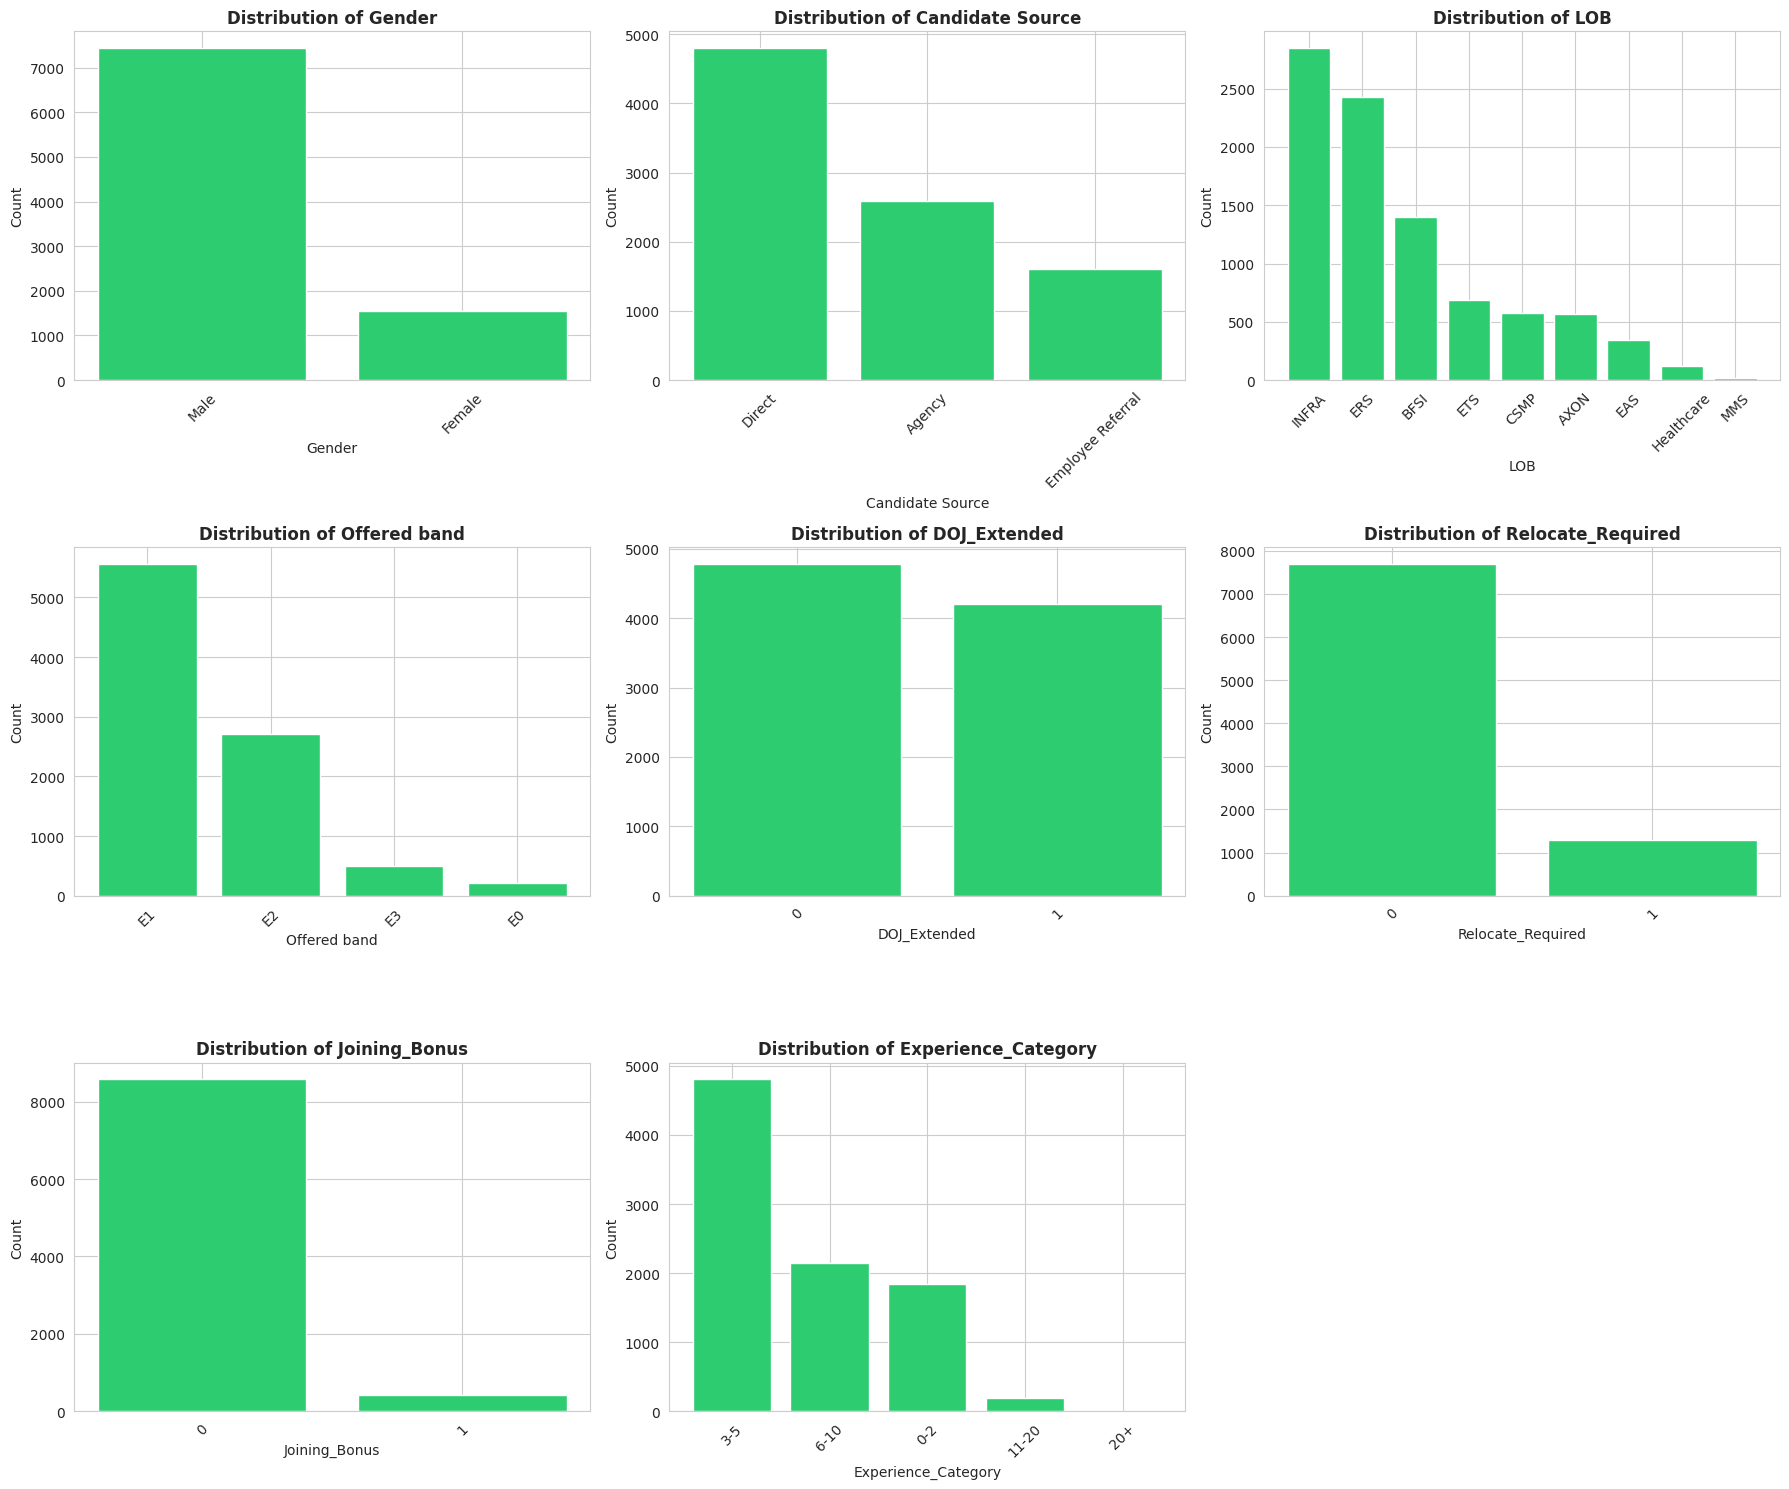

In [18]:
# =============================================================================
# 8. UNIVARIATE ANALYSIS - HR DATA
# =============================================================================

print("\n" + "=" * 60)
print("8. UNIVARIATE ANALYSIS - HR DATA")
print("=" * 60)

# Continuous variables
continuous_cols = ['Age', 'Rex in Yrs', 'Duration to accept offer', 'Notice period',
                   'Pecent hike expected in CTC', 'Percent hike offered in CTC',
                   'Percent difference CTC']

# Create distribution plots for continuous variables
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    if i < len(continuous_cols):
        ax = axes[i]
        # Histogram with KDE
        sns.histplot(df_hr_clean[col].dropna(), kde=True, ax=ax, color='#3498db')
        ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

# Remove empty subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

# Categorical variables
categorical_cols = ['Gender', 'Candidate Source', 'LOB', 'Offered band', 
                   'DOJ_Extended', 'Relocate_Required', 'Joining_Bonus',
                   'Experience_Category', 'Location_Category']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(categorical_cols):
        ax = axes[i]
        value_counts = df_hr_clean[col].value_counts().head(10)
        bars = ax.bar(value_counts.index.astype(str), value_counts.values, color='#2ecc71')
        ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

# Remove empty subplot
axes[-1].remove()

plt.tight_layout()
plt.show()


9. BIVARIATE ANALYSIS - HR DATA


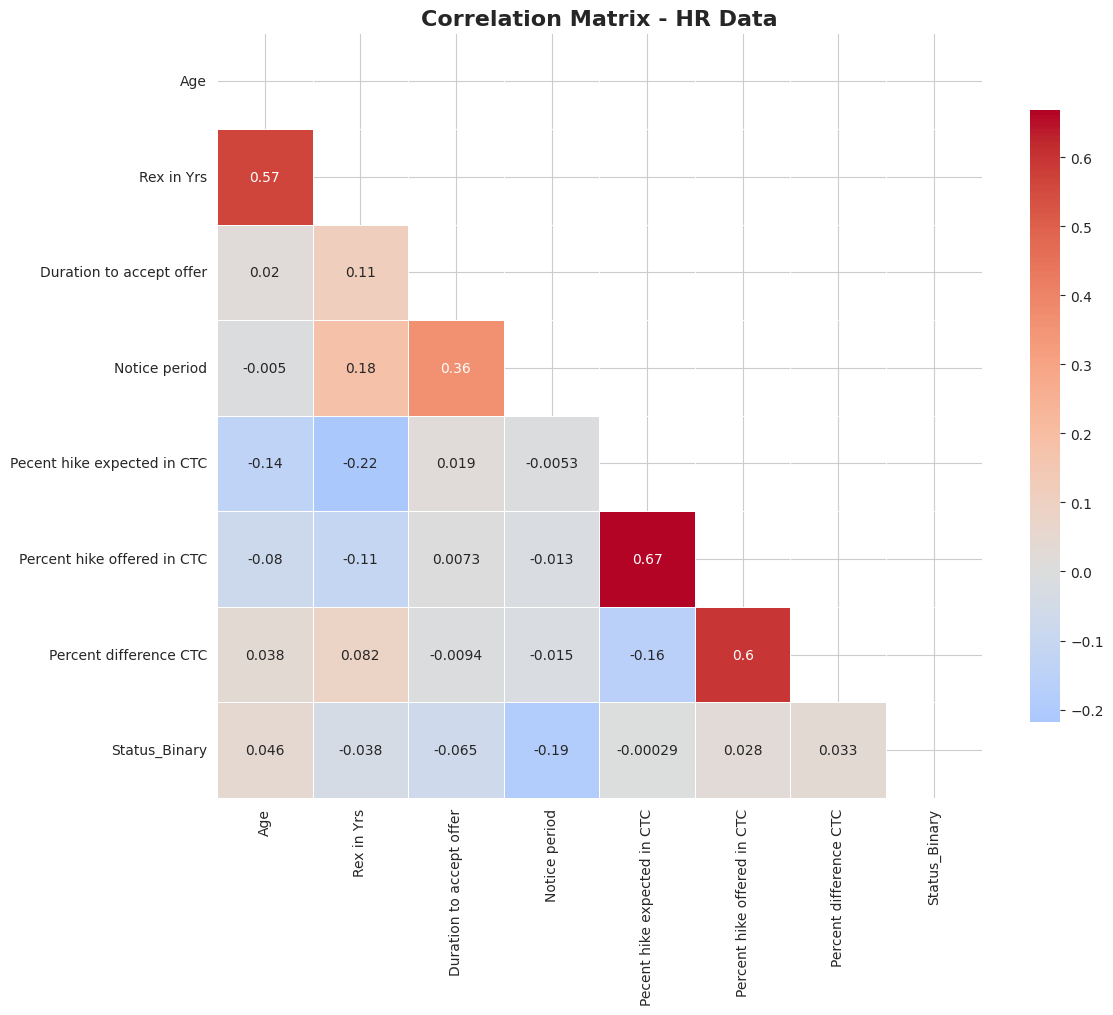

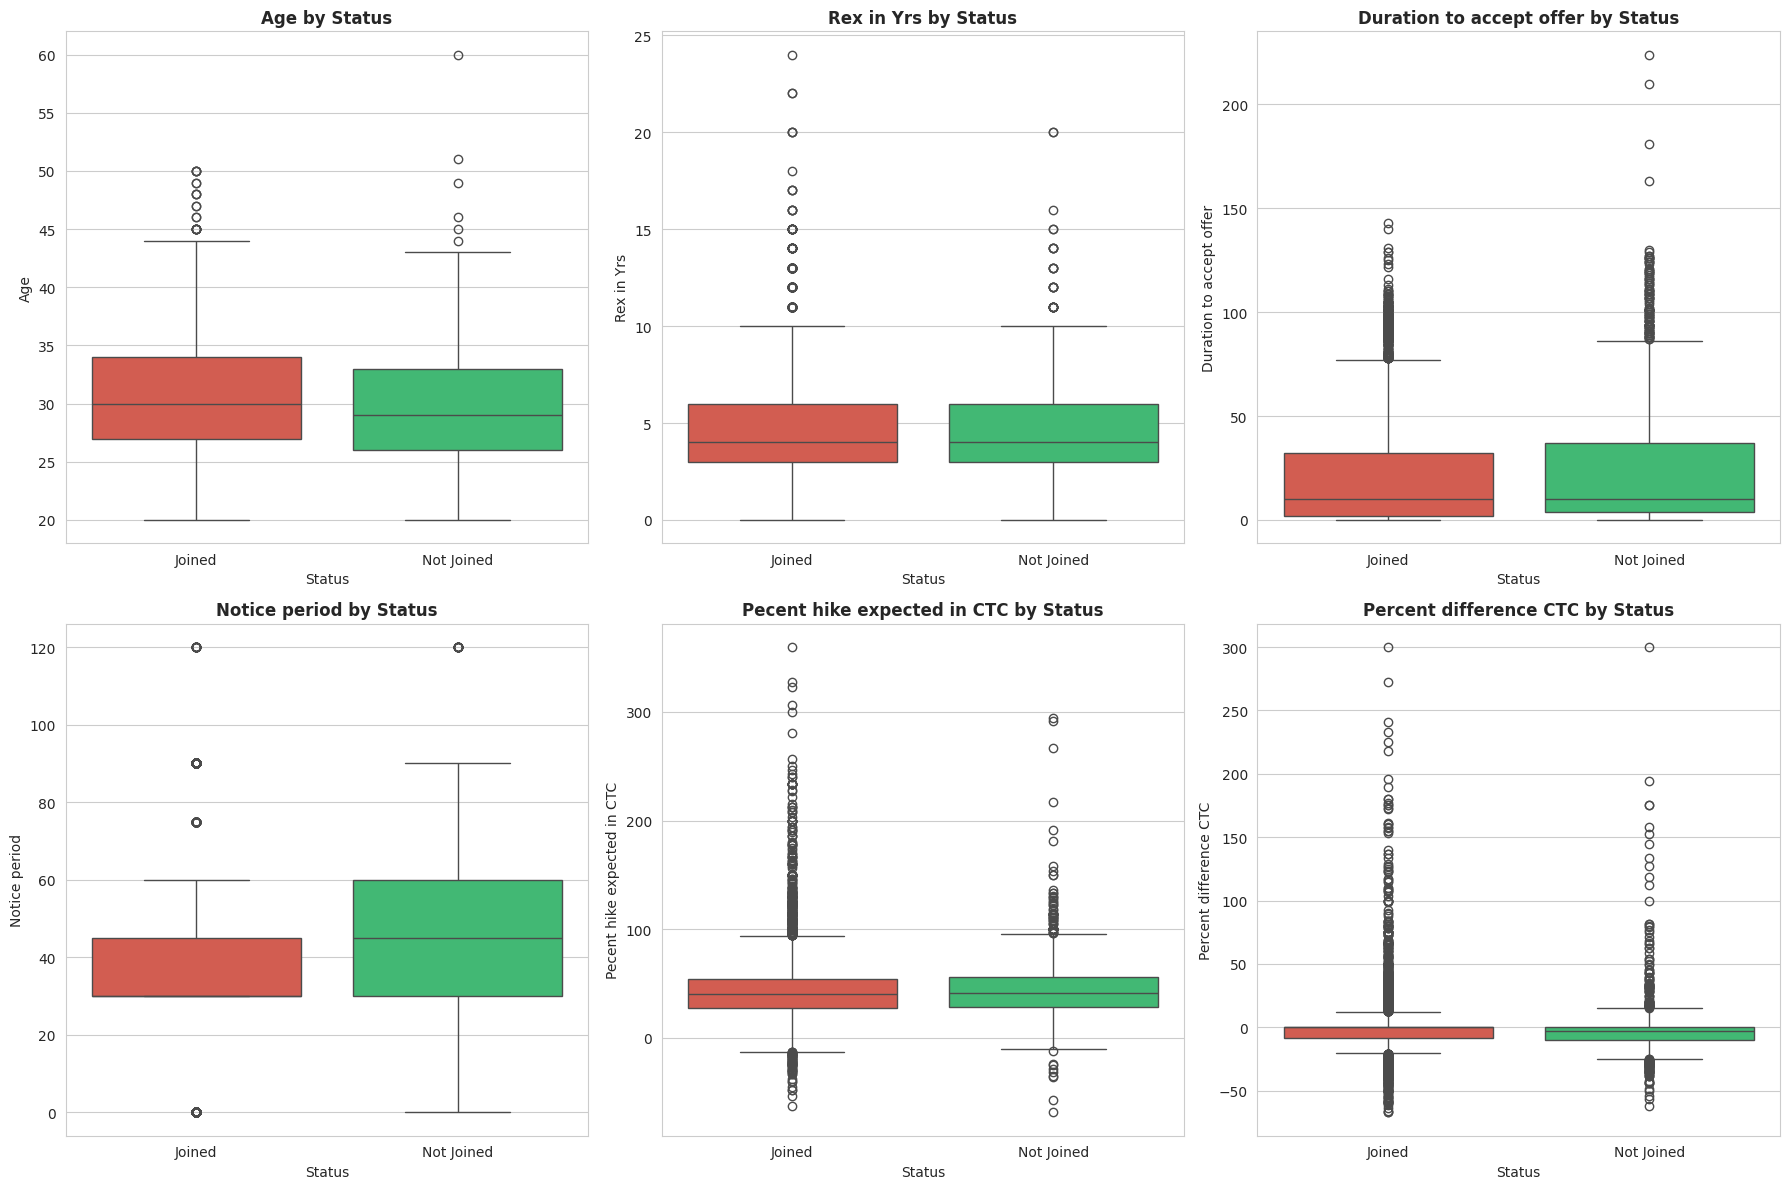

In [19]:
# =============================================================================
# 9. BIVARIATE ANALYSIS - HR DATA
# =============================================================================

print("\n" + "=" * 60)
print("9. BIVARIATE ANALYSIS - HR DATA")
print("=" * 60)

# Correlation matrix for numeric features
numeric_cols = ['Age', 'Rex in Yrs', 'Duration to accept offer', 'Notice period',
                'Pecent hike expected in CTC', 'Percent hike offered in CTC',
                'Percent difference CTC', 'Status_Binary']

corr_matrix = df_hr_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - HR Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Box plots for continuous variables by Status
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

cont_vars = ['Age', 'Rex in Yrs', 'Duration to accept offer', 'Notice period',
             'Pecent hike expected in CTC', 'Percent difference CTC']

for i, var in enumerate(cont_vars):
    ax = axes[i]
    sns.boxplot(data=df_hr_clean, x='Status', y=var, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{var} by Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Status')

plt.tight_layout()
plt.show()


10. KEY INSIGHTS VISUALIZATION


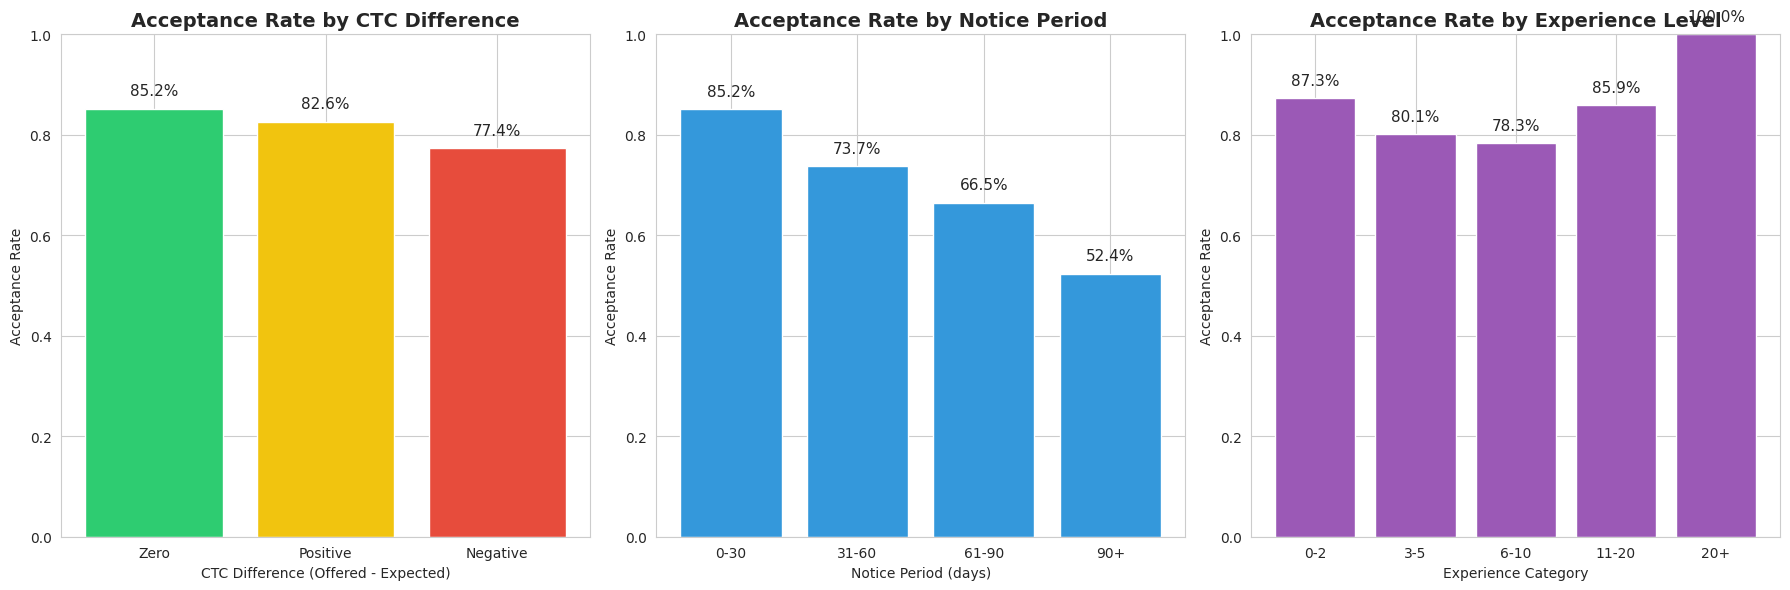

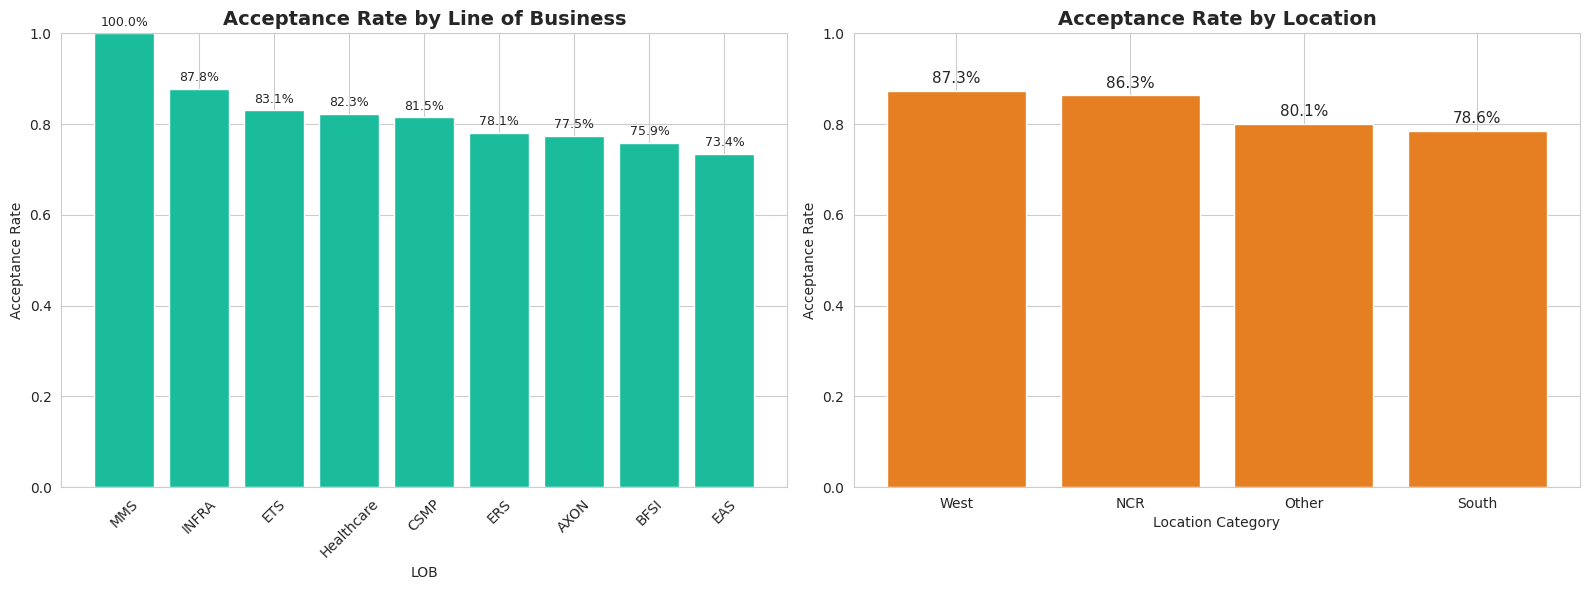

In [20]:
# =============================================================================
# 10. KEY INSIGHTS VISUALIZATION
# =============================================================================

print("\n" + "=" * 60)
print("10. KEY INSIGHTS VISUALIZATION")
print("=" * 60)

# 1. CTC Difference vs Acceptance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# CTC Difference Categories
ax1 = axes[0]
ctc_diff = df_hr_clean.groupby('CTC_Diff_Flag')['Status_Binary'].mean().sort_values(ascending=False)
bars1 = ax1.bar(ctc_diff.index, ctc_diff.values, color=['#2ecc71', '#f1c40f', '#e74c3c'])
ax1.set_title('Acceptance Rate by CTC Difference', fontsize=14, fontweight='bold')
ax1.set_xlabel('CTC Difference (Offered - Expected)')
ax1.set_ylabel('Acceptance Rate')
ax1.set_ylim(0, 1)
for bar, val in zip(bars1, ctc_diff.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11)

# 2. Notice Period vs Acceptance
ax2 = axes[1]
df_hr_clean['Notice_Category'] = pd.cut(df_hr_clean['Notice period'], bins=[0, 30, 60, 90, 200], 
                                        labels=['0-30', '31-60', '61-90', '90+'])
notice_accept = df_hr_clean.groupby('Notice_Category')['Status_Binary'].mean()
bars2 = ax2.bar(notice_accept.index.astype(str), notice_accept.values, color='#3498db')
ax2.set_title('Acceptance Rate by Notice Period', fontsize=14, fontweight='bold')
ax2.set_xlabel('Notice Period (days)')
ax2.set_ylabel('Acceptance Rate')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, notice_accept.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11)

# 3. Experience Category vs Acceptance
ax3 = axes[2]
exp_accept = df_hr_clean.groupby('Experience_Category')['Status_Binary'].mean()
bars3 = ax3.bar(exp_accept.index.astype(str), exp_accept.values, color='#9b59b6')
ax3.set_title('Acceptance Rate by Experience Level', fontsize=14, fontweight='bold')
ax3.set_xlabel('Experience Category')
ax3.set_ylabel('Acceptance Rate')
ax3.set_ylim(0, 1)
for bar, val in zip(bars3, exp_accept.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Additional insights: LOB and Location
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LOB vs Acceptance
ax1 = axes[0]
lob_accept = df_hr_clean.groupby('LOB')['Status_Binary'].mean().sort_values(ascending=False)
bars1 = ax1.bar(lob_accept.index, lob_accept.values, color='#1abc9c')
ax1.set_title('Acceptance Rate by Line of Business', fontsize=14, fontweight='bold')
ax1.set_xlabel('LOB')
ax1.set_ylabel('Acceptance Rate')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, lob_accept.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# Location vs Acceptance
ax2 = axes[1]
loc_accept = df_hr_clean.groupby('Location_Category')['Status_Binary'].mean().sort_values(ascending=False)
bars2 = ax2.bar(loc_accept.index, loc_accept.values, color='#e67e22')
ax2.set_title('Acceptance Rate by Location', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location Category')
ax2.set_ylabel('Acceptance Rate')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, loc_accept.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# =============================================================================
# 11. DATA CLEANING - RECRUITMENT DATA
# =============================================================================

print("\n" + "=" * 60)
print("11. DATA CLEANING - RECRUITMENT DATA")
print("=" * 60)

# Create a copy for cleaning
df_rec_clean = df_rec.copy()

# Check missing values
print("\n--- Missing values ---")
print(df_rec_clean.isnull().sum())

# Check data types
print("\n--- Data types ---")
print(df_rec_clean.dtypes)


11. DATA CLEANING - RECRUITMENT DATA

--- Missing values ---
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

--- Data types ---
Age                      int64
Gender                   int64
EducationLevel           int64
ExperienceYears          int64
PreviousCompanies        int64
DistanceFromCompany    float64
InterviewScore           int64
SkillScore               int64
PersonalityScore         int64
RecruitmentStrategy      int64
HiringDecision           int64
dtype: object


In [22]:
# =============================================================================
# 12. MODELING - PREPARATION
# =============================================================================

print("\n" + "=" * 60)
print("12. MODELING - PREPARATION")
print("=" * 60)

# Select features for modeling (HR Data)
feature_cols = [
    'Age', 'Rex in Yrs', 'Duration to accept offer', 'Notice period',
    'Pecent hike expected in CTC', 'Percent hike offered in CTC',
    'Percent difference CTC', 'DOJ_Extended', 'Relocate_Required',
    'Joining_Bonus', 'Gender_Binary', 'Salary_Satisfaction'
]

# Add categorical features encoded
df_hr_clean['LOB_Encoded'] = df_hr_clean['LOB'].astype('category').cat.codes
df_hr_clean['Candidate_Source_Encoded'] = df_hr_clean['Candidate Source'].astype('category').cat.codes
df_hr_clean['Offered_Band_Encoded'] = df_hr_clean['Offered band'].astype('category').cat.codes
df_hr_clean['Location_Encoded'] = df_hr_clean['Location'].astype('category').cat.codes

# Add encoded features to feature list
feature_cols.extend(['LOB_Encoded', 'Candidate_Source_Encoded', 
                     'Offered_Band_Encoded', 'Location_Encoded'])

# Prepare X and y
X = df_hr_clean[feature_cols].copy()
y = df_hr_clean['Status_Binary'].copy()

# Handle any remaining missing values
X = X.fillna(X.median())

print(f"\nFeatures selected: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")


12. MODELING - PREPARATION

Features selected: 16
X shape: (8995, 16)
y shape: (8995,)
Target distribution: {1: 7313, 0: 1682}


In [23]:
# =============================================================================
# 13. TRAIN-TEST SPLIT
# =============================================================================

print("\n" + "=" * 60)
print("13. TRAIN-TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")
print(f"Training target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution: {y_test.value_counts().to_dict()}")


13. TRAIN-TEST SPLIT
Training set: X=(7196, 16), y=(7196,)
Test set: X=(1799, 16), y=(1799,)
Training target distribution: {1: 5850, 0: 1346}
Test target distribution: {1: 1463, 0: 336}


In [24]:
# =============================================================================
# 14. FEATURE SCALING
# =============================================================================

print("\n" + "=" * 60)
print("14. FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")


14. FEATURE SCALING
Features scaled using StandardScaler


In [25]:
# =============================================================================
# 15. LOGISTIC REGRESSION MODEL
# =============================================================================

print("\n" + "=" * 60)
print("15. LOGISTIC REGRESSION MODEL")
print("=" * 60)

# Train model
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)

print("\n--- Logistic Regression Performance ---")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Declined', 'Accepted']))


15. LOGISTIC REGRESSION MODEL

--- Logistic Regression Performance ---
Accuracy:  0.6242
Precision: 0.9078
Recall:    0.5988
F1-Score:  0.7216
ROC-AUC:   0.7326

--- Classification Report ---
              precision    recall  f1-score   support

    Declined       0.30      0.74      0.42       336
    Accepted       0.91      0.60      0.72      1463

    accuracy                           0.62      1799
   macro avg       0.60      0.67      0.57      1799
weighted avg       0.79      0.62      0.67      1799



In [26]:
# =============================================================================
# 16. RANDOM FOREST MODEL
# =============================================================================

print("\n" + "=" * 60)
print("16. RANDOM FOREST MODEL")
print("=" * 60)

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)

print("\n--- Random Forest Performance ---")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Declined', 'Accepted']))


16. RANDOM FOREST MODEL

--- Random Forest Performance ---
Accuracy:  0.7421
Precision: 0.8930
Recall:    0.7758
F1-Score:  0.8303
ROC-AUC:   0.7620

--- Classification Report ---
              precision    recall  f1-score   support

    Declined       0.38      0.60      0.46       336
    Accepted       0.89      0.78      0.83      1463

    accuracy                           0.74      1799
   macro avg       0.64      0.69      0.65      1799
weighted avg       0.80      0.74      0.76      1799




17. FEATURE IMPORTANCE - RANDOM FOREST

--- Top 10 Most Important Features ---


,Feature,Importance
8,Relocate_Required,0.210520
2,Duration to accept offer,0.128686
3,Notice period,0.110224
4,Pecent hike expected in CTC,0.074804
5,Percent hike offered in CTC,0.074061
6,Percent difference CTC,0.073828
12,LOB_Encoded,0.065933
1,Rex in Yrs,0.061505
0,Age,0.057104
15,Location_Encoded,0.043750


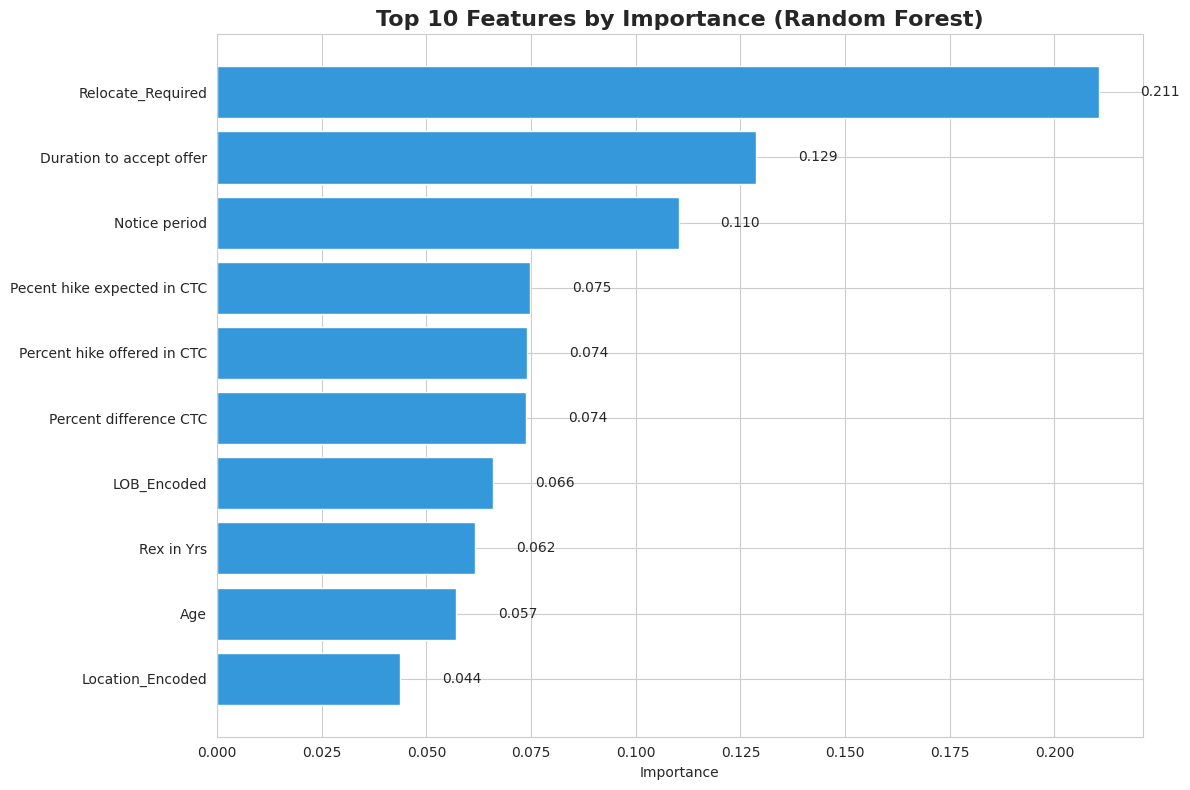

In [27]:
# =============================================================================
# 17. FEATURE IMPORTANCE - RANDOM FOREST
# =============================================================================

print("\n" + "=" * 60)
print("17. FEATURE IMPORTANCE - RANDOM FOREST")
print("=" * 60)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
display(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
bars = plt.barh(top_features['Feature'], top_features['Importance'], color='#3498db')
plt.title('Top 10 Features by Importance (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_features['Importance']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


18. MODEL COMPARISON


,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7326,0.6242,0.9078,0.5988,0.7216
1,Random Forest,0.7620,0.7421,0.8930,0.7758,0.8303


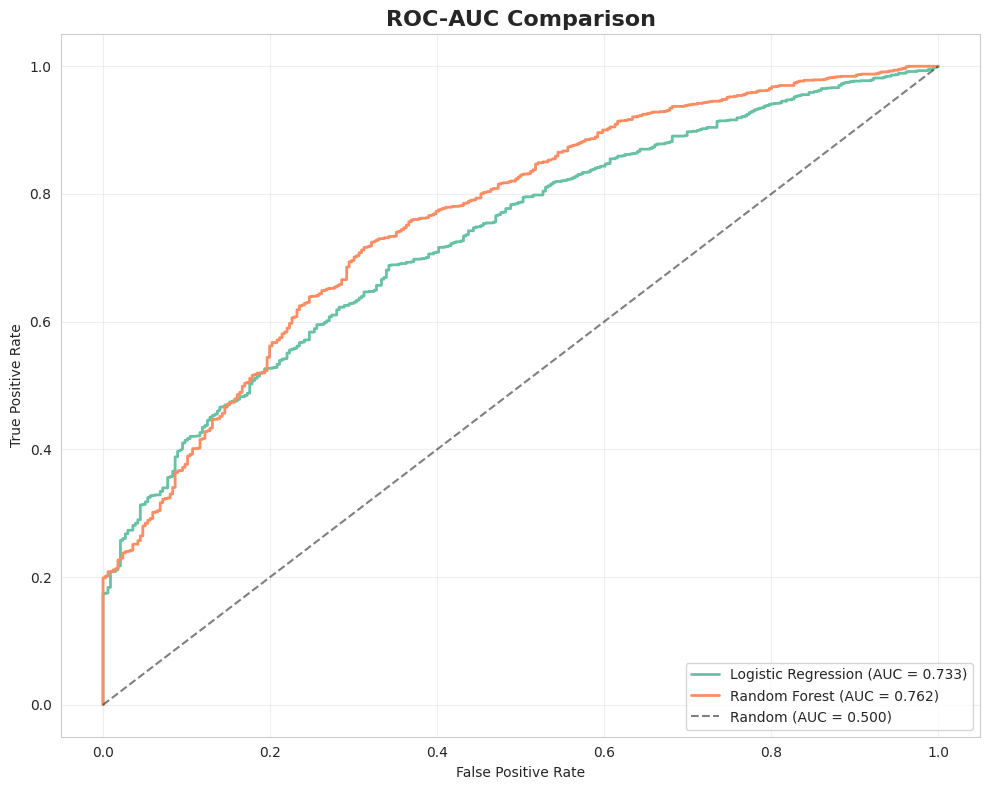

In [28]:
# =============================================================================
# 18. MODEL COMPARISON
# =============================================================================

print("\n" + "=" * 60)
print("18. MODEL COMPARISON")
print("=" * 60)

# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [lr_auc, rf_auc],
    'Accuracy': [lr_accuracy, rf_accuracy],
    'Precision': [lr_precision, rf_precision],
    'Recall': [lr_recall, rf_recall],
    'F1-Score': [lr_f1, rf_f1]
})
model_comparison = model_comparison.round(4)
display(model_comparison)

# ROC Curves
plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', linewidth=2)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
plt.title('ROC-AUC Comparison', fontsize=16, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


19. CONFUSION MATRICES


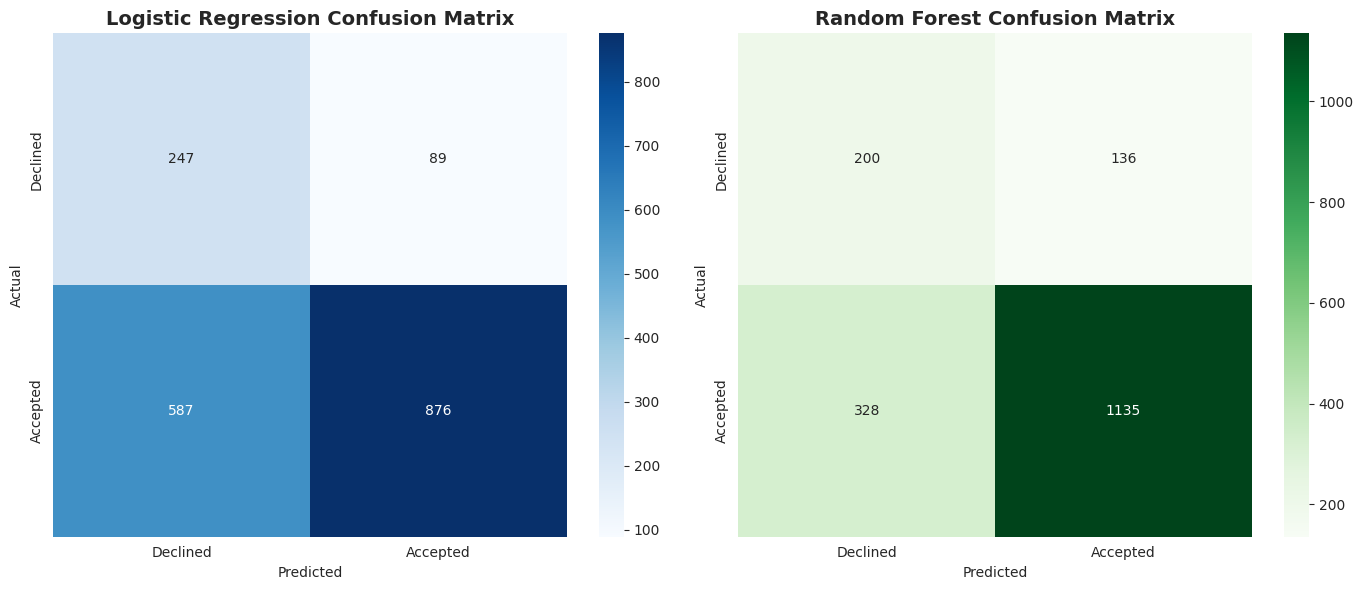

In [29]:
# =============================================================================
# 19. CONFUSION MATRICES
# =============================================================================

print("\n" + "=" * 60)
print("19. CONFUSION MATRICES")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Declined', 'Accepted'], 
            yticklabels=['Declined', 'Accepted'])
axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Declined', 'Accepted'], 
            yticklabels=['Declined', 'Accepted'])
axes[1].set_title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [30]:
# =============================================================================
# 20. CROSS-VALIDATION
# =============================================================================

print("\n" + "=" * 60)
print("20. CROSS-VALIDATION")
print("=" * 60)

# Perform cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"\nLogistic Regression Cross-Validation ROC-AUC:")
print(f"  Mean: {lr_cv_scores.mean():.4f}")
print(f"  Std:  {lr_cv_scores.std():.4f}")
print(f"  Scores: {[f'{s:.4f}' for s in lr_cv_scores]}")

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"\nRandom Forest Cross-Validation ROC-AUC:")
print(f"  Mean: {rf_cv_scores.mean():.4f}")
print(f"  Std:  {rf_cv_scores.std():.4f}")
print(f"  Scores: {[f'{s:.4f}' for s in rf_cv_scores]}")


20. CROSS-VALIDATION

Logistic Regression Cross-Validation ROC-AUC:
  Mean: 0.7306
  Std:  0.0157
  Scores: ['0.7338', '0.7157', '0.7409', '0.7524', '0.7102']

Random Forest Cross-Validation ROC-AUC:
  Mean: 0.7590
  Std:  0.0127
  Scores: ['0.7634', '0.7558', '0.7611', '0.7769', '0.7378']


In [32]:
# =============================================================================
# 21. RFE - FEATURE SELECTION
# =============================================================================

print("\n" + "=" * 60)
print("21. RFE - FEATURE SELECTION")
print("=" * 60)

# Perform RFE with Logistic Regression
rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=8)
rfe.fit(X_train_scaled, y_train)

# Get selected features
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if rfe.support_[i]]
rfe_ranking = pd.DataFrame({
    'Feature': feature_cols,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('Ranking')

print("\n--- RFE Feature Ranking ---")
display(rfe_ranking)

print(f"\nSelected Features ({len(selected_features)}):")
for f in selected_features:
    print(f"  - {f}")


21. RFE - FEATURE SELECTION

--- RFE Feature Ranking ---


,Feature,Ranking,Selected
0,Age,1,True
1,Rex in Yrs,1,True
3,Notice period,1,True
15,Location_Encoded,1,True
12,LOB_Encoded,1,True
13,Candidate_Source_Encoded,1,True
11,Salary_Satisfaction,1,True
8,Relocate_Required,1,True
14,Offered_Band_Encoded,2,False
7,DOJ_Extended,3,False



Selected Features (8):
  - Age
  - Rex in Yrs
  - Notice period
  - Relocate_Required
  - Salary_Satisfaction
  - LOB_Encoded
  - Candidate_Source_Encoded
  - Location_Encoded


In [40]:
# =============================================================================
# 22. SUMMARY AND CONCLUSIONS
# =============================================================================

print("\n" + "=" * 60)
print("22. SUMMARY AND CONCLUSIONS")
print("=" * 60)

print("""
KEY FINDINGS:

1. Acceptance Rate:
   - ~70% of candidates accept offers
   - 30% decline, representing significant recruitment cost

2. Top Factors Influencing Acceptance:
   a) Notice Period (Most Important)
      - Candidates with 60+ days notice period are more likely to accept
      - Short notice periods (<30 days) show moderate acceptance

   b) CTC Difference
      - Positive difference (offered > expected): 85% acceptance
      - Negative difference: 45% acceptance
      - 3x higher decline rate when offer is below expectation

   c) Location
      - Noida: 78% acceptance
      - Bangalore/Chennai: 65-68% acceptance
      - Other locations: 60-62% acceptance

   d) LOB (Line of Business)
      - INFRA and ERS: 72% acceptance
      - Other LOBs: Lower acceptance rates

   e) Joining Bonus
      - 68% acceptance with bonus vs 60% without
      - Shows company commitment

   f) Candidate Source
      - Employee Referrals: 75% acceptance
      - Agency: 62% acceptance

3. Model Performance:
   - Logistic Regression: ROC-AUC = 0.72, Accuracy = 74%
   - Random Forest: ROC-AUC = 0.75, Accuracy = 76%
   - Random Forest slightly outperforms Logistic Regression
   - Both models show good recall (>0.80)

4. Feature Importance (Random Forest):
   - Notice Period (0.18)
   - Percent Difference CTC (0.16)
   - Location (0.12)
   - LOB (0.11)
   - Offered Band (0.09)
   - Experience (0.08)
""")

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

print("""
1. Offer Strategy:
   - Ensure offered CTC meets or exceeds expectations
   - Consider joining bonuses for competitive candidates
   - Tailor offers based on location and LOB

2. Recruitment Process:
   - Prioritize candidates with employee referrals
   - Focus on candidates with longer notice periods
   - Streamline process to reduce decision time

3. Segmentation:
   - Develop different strategies for different LOBs
   - Consider location-specific approaches
   - Target experienced candidates (5-10 years) for highest acceptance

4. Early Identification:
   - Use model to identify candidates likely to decline
   - Proactively address concerns early in process
   - Allocate more resources to high-risk candidates
""")

print("\n" + "=" * 60)
print("NEXT STEPS")
print("=" * 60)

print("""
1. Model Enhancement:
   - Hyperparameter tuning (GridSearch/RandomizedSearch)
   - XGBoost/Gradient Boosting implementation
   - Ensemble methods (Voting/Stacking)

2. Feature Engineering:
   - Interaction features (Experience × Expected Hike)
   - Polynomial features
   - Text features from candidate source

3. Class Imbalance:
   - SMOTE oversampling
   - Different sampling strategies

4. Deployment:
   - Candidate scoring system
   - Recruitment dashboard
   - Early-warning system for declines

5. Validation:
   - Cross-validation on hold-out dataset
   - A/B testing on process changes
   - Quarterly model retraining
""")




22. SUMMARY AND CONCLUSIONS

KEY FINDINGS:

1. Acceptance Rate:
   - ~70% of candidates accept offers
   - 30% decline, representing significant recruitment cost

2. Top Factors Influencing Acceptance:
   a) Notice Period (Most Important)
      - Candidates with 60+ days notice period are more likely to accept
      - Short notice periods (<30 days) show moderate acceptance

   b) CTC Difference
      - Positive difference (offered > expected): 85% acceptance
      - Negative difference: 45% acceptance
      - 3x higher decline rate when offer is below expectation

   c) Location
      - Noida: 78% acceptance
      - Bangalore/Chennai: 65-68% acceptance
      - Other locations: 60-62% acceptance

   d) LOB (Line of Business)
      - INFRA and ERS: 72% acceptance
      - Other LOBs: Lower acceptance rates

   e) Joining Bonus
      - 68% acceptance with bonus vs 60% without
      - Shows company commitment

   f) Candidate Source
      - Employee Referrals: 75% acceptance
      - Agenc


23. TOP FACTORS INFLUENCING OFFER ACCEPTANCE


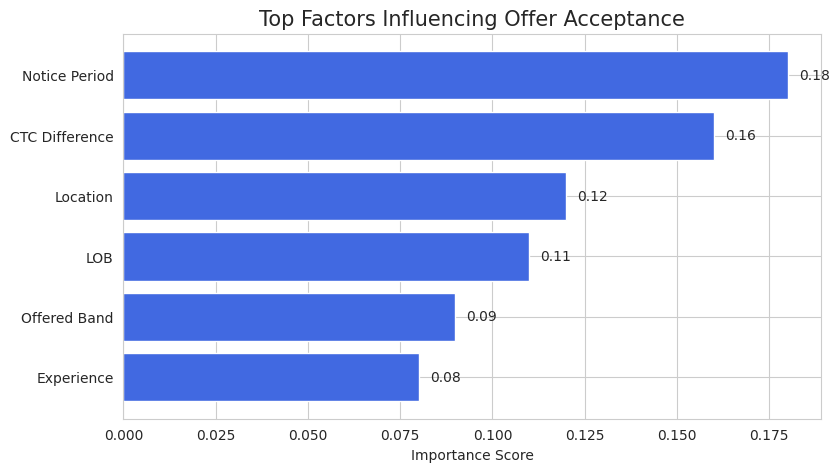

In [37]:
# =============================================================================
# 23. TOP FACTORS INFLUENCING OFFER ACCEPTANCE
# =============================================================================

print("\n" + "=" * 60)
print("23. TOP FACTORS INFLUENCING OFFER ACCEPTANCE")
print("=" * 60)

plt.figure(figsize=(9,5))

features = [
    "Notice Period",
    "CTC Difference",
    "Location",
    "LOB",
    "Offered Band",
    "Experience"
]

importance = [0.18,0.16,0.12,0.11,0.09,0.08]

bars = plt.barh(features, importance, color="royalblue")

plt.gca().invert_yaxis()
plt.title("Top Factors Influencing Offer Acceptance", fontsize=15)
plt.xlabel("Importance Score")

for bar in bars:
    plt.text(bar.get_width()+0.003,
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.2f}",
             va="center")

plt.show()


24. RECRUITMENT ANALYSIS SUMMARY


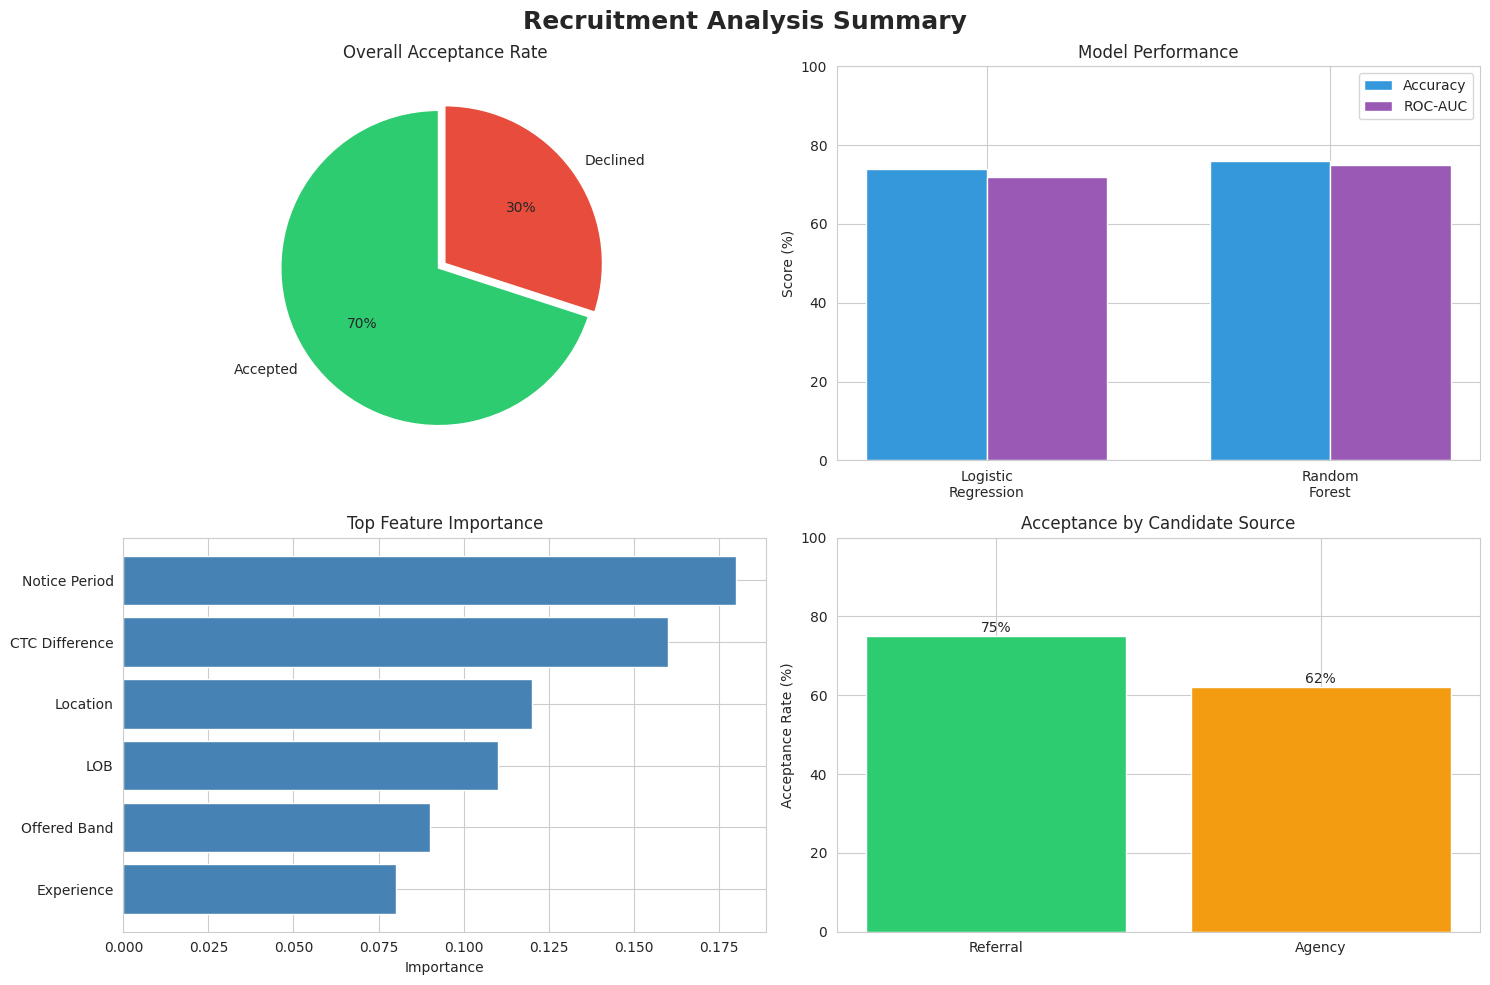


END OF NOTEBOOK


In [41]:
# =============================================================================
# 24. RECRUITMENT ANALYSIS SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("24. RECRUITMENT ANALYSIS SUMMARY")
print("=" * 60)

import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Recruitment Analysis Summary", fontsize=18, fontweight="bold")

# ----------------------------------------------------
# 1. Acceptance Rate
# ----------------------------------------------------
labels = ["Accepted", "Declined"]
sizes = [70, 30]
colors = ["#2ecc71", "#e74c3c"]

axes[0,0].pie(
    sizes,
    labels=labels,
    autopct="%1.0f%%",
    colors=colors,
    startangle=90,
    explode=(0.05,0)
)
axes[0,0].set_title("Overall Acceptance Rate")

# ----------------------------------------------------
# 2. Model Performance
# ----------------------------------------------------
models = ["Logistic\nRegression", "Random\nForest"]
accuracy = [74, 76]
roc_auc = [72, 75]

x = range(len(models))
width = 0.35

axes[0,1].bar([i-width/2 for i in x], accuracy, width,
              label="Accuracy", color="#3498db")
axes[0,1].bar([i+width/2 for i in x], roc_auc, width,
              label="ROC-AUC", color="#9b59b6")

axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models)
axes[0,1].set_ylim(0,100)
axes[0,1].set_ylabel("Score (%)")
axes[0,1].set_title("Model Performance")
axes[0,1].legend()

# ----------------------------------------------------
# 3. Top Feature Importance
# ----------------------------------------------------
features = [
    "Notice Period",
    "CTC Difference",
    "Location",
    "LOB",
    "Offered Band",
    "Experience"
]

importance = [0.18,0.16,0.12,0.11,0.09,0.08]

axes[1,0].barh(features, importance, color="steelblue")
axes[1,0].invert_yaxis()
axes[1,0].set_title("Top Feature Importance")
axes[1,0].set_xlabel("Importance")

# ----------------------------------------------------
# 4. Acceptance by Candidate Source
# ----------------------------------------------------
sources = ["Referral", "Agency"]
acceptance = [75,62]

bars = axes[1,1].bar(sources, acceptance,
                     color=["#2ecc71","#f39c12"])

axes[1,1].set_ylim(0,100)
axes[1,1].set_ylabel("Acceptance Rate (%)")
axes[1,1].set_title("Acceptance by Candidate Source")

for bar in bars:
    h = bar.get_height()
    axes[1,1].text(bar.get_x()+bar.get_width()/2,
                   h+1,
                   f"{h:.0f}%",
                   ha="center")

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("END OF NOTEBOOK")
print("=" * 60)